# Model Evaluation and Performance Comparison

This notebook evaluates and compares all trained models for brain tumor MRI classification.

Models included:
- Simple CNN (Baseline)
- MobileNet Baseline
- MobileNet Partial Unfreeze
- MobileNet Block Unfreeze
- ResNet (to be added later)

Evaluation is performed on the raw test dataset.

## 1) Import Libraries

This section imports all required libraries for loading trained models, running evaluation, generating metrics, and visualizing results.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.models as models
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

sys.path.append(os.path.abspath(".."))

from src.dataset import BrainTumorDataset
from src.transforms import train_transform, test_transform
from src.trainer import train_model
from src.simple_cnn import SimpleCNN

## 2) Configuration

This section defines paths, device configuration, batch size, and class labels used during evaluation.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
TEST_DIR = "../data/raw/test"
CLASS_NAMES = ["glioma","meningioma","no_tumor","pituitary"]
NUM_CLASSES = len(CLASS_NAMES)

CLASS_TO_IDX = {
    "glioma": 0,
    "meningioma": 1,
    "no_tumor": 2,
    "pituitary": 3
}

MODEL_PATHS = {
    "Simple CNN": "../models/baseline_cnn.pth",
    "MobileNet Baseline": "../models/mobilenet_baseline.pth",
    "MobileNet Partial Unfreeze": "../models/mobilenet_partial_unfreeze.pth",
    "MobileNet Block Unfreeze": "../models/mobilenet_block_unfreeze.pth",
    # "ResNet": "../models/resnet.pth"
}

print("Device:", DEVICE)

Device: cuda


## 3) Load Test Dataset

This section prepares the processed test dataset for final evaluation.

The evaluation uses only test preprocessing without augmentation.

In [3]:
test_root = Path(TEST_DIR)
image_paths = []
labels = []

for class_name in CLASS_NAMES:
    class_folder = test_root / class_name
    for img_path in class_folder.glob("*"):
        image_paths.append(str(img_path))
        labels.append(CLASS_TO_IDX[class_name])

test_dataset = BrainTumorDataset(
    image_paths=image_paths,
    labels=labels,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test samples:", len(test_dataset))

Test samples: 1000


## 4) Model Loader

This function reconstructs the correct architecture based on the selected experiment and loads corresponding trained weights.

The architecture is automatically selected according to the model name.

In [4]:
def load_model(name, path):

    if name == "Simple CNN":
        model = SimpleCNN()
    else:
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)

    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    return model

## 5) Evaluation Function

This function performs model evaluation by generating predictions and computing performance metrics.

In [5]:
def evaluate(model):

    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE)
            out = model(x)
            prob = torch.softmax(out, dim=1)
            pred = torch.argmax(prob, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

## 6) Metrics & Confusion Matrix & ROC

This section calculates evaluation metrics and visualizes model performance using a confusion matrix.

We use:

- Accuracy
- Precision
- Recall
- F1-score

In [6]:
def compute_metrics(y_true, y_pred, y_prob):

    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1": f1_score(y_true, y_pred, average="weighted"),
        "AUC": roc_auc_score(y_true_bin, y_prob, multi_class="ovr")
    }

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.show()

def plot_roc(y_true, y_prob, title):
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(8,6))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'--')
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## 7)  Evaluate All Models
This section runs evaluation on all trained models and stores their performance for final comparison.


Model: Simple CNN
              precision    recall  f1-score   support

      glioma       0.90      0.64      0.74       254
  meningioma       0.69      0.62      0.65       306
    no_tumor       0.65      0.99      0.79       140
   pituitary       0.87      0.97      0.91       300

    accuracy                           0.78      1000
   macro avg       0.78      0.80      0.78      1000
weighted avg       0.79      0.78      0.77      1000



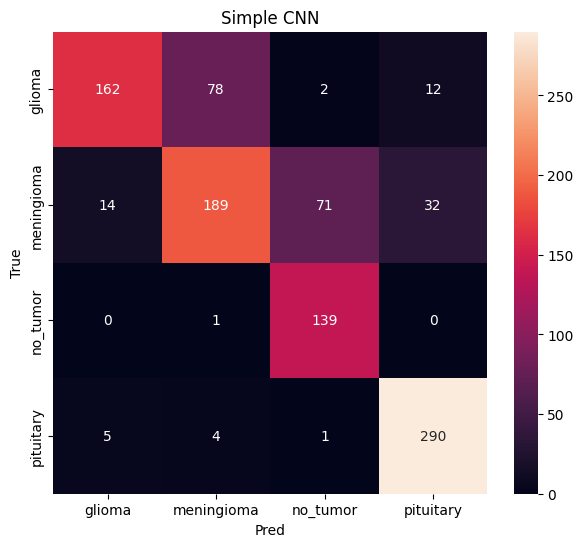

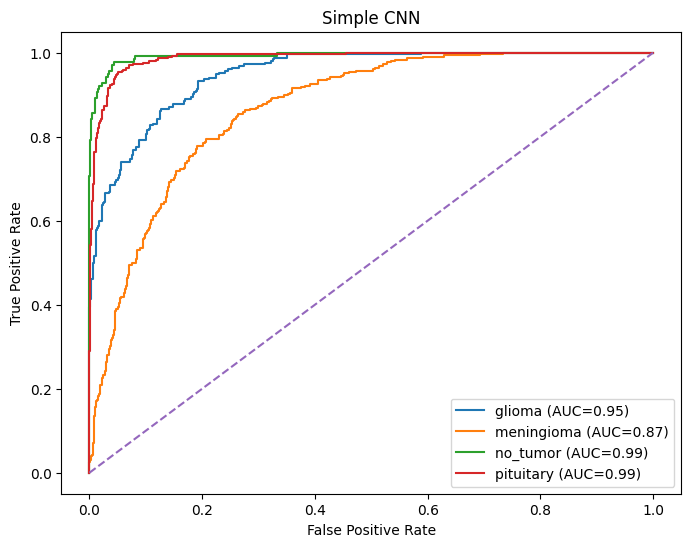


Model: MobileNet Baseline
              precision    recall  f1-score   support

      glioma       0.83      0.71      0.77       254
  meningioma       0.69      0.53      0.60       306
    no_tumor       0.59      0.96      0.73       140
   pituitary       0.84      0.90      0.87       300

    accuracy                           0.75      1000
   macro avg       0.74      0.77      0.74      1000
weighted avg       0.76      0.75      0.74      1000



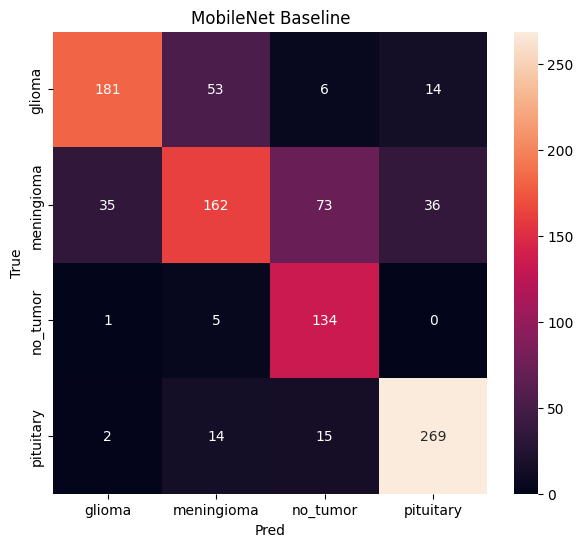

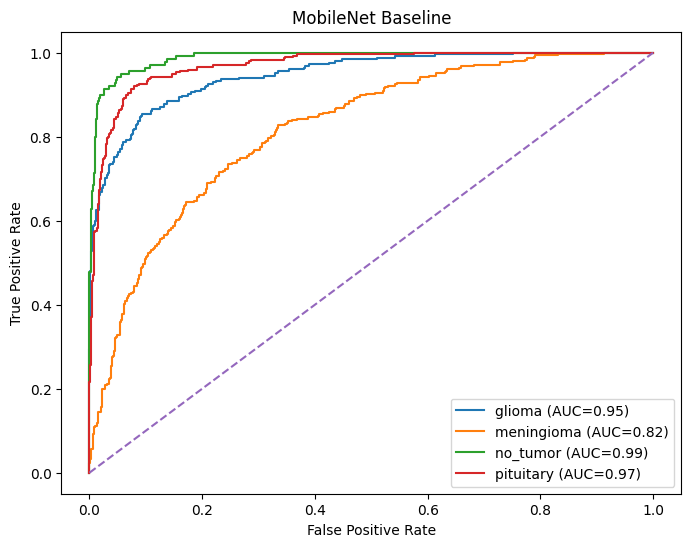


Model: MobileNet Partial Unfreeze
              precision    recall  f1-score   support

      glioma       0.95      0.86      0.90       254
  meningioma       0.87      0.86      0.86       306
    no_tumor       0.89      1.00      0.94       140
   pituitary       0.94      0.97      0.96       300

    accuracy                           0.91      1000
   macro avg       0.91      0.92      0.92      1000
weighted avg       0.92      0.91      0.91      1000



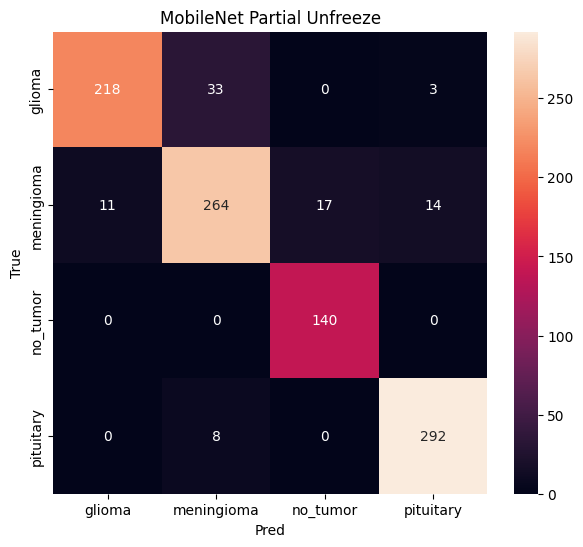

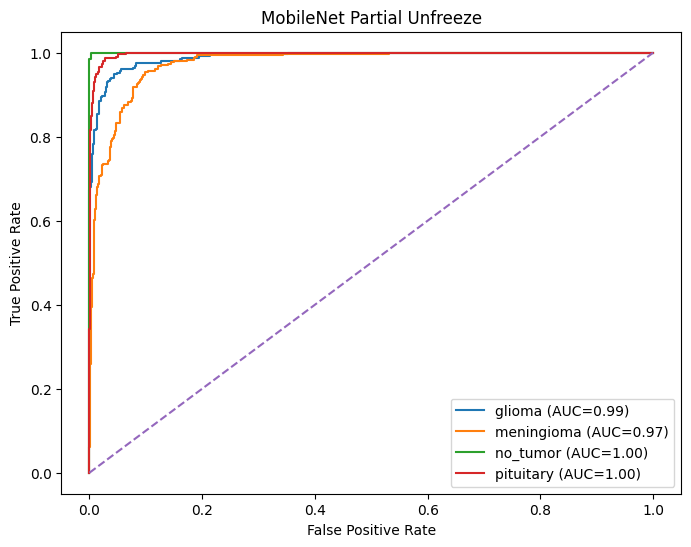


Model: MobileNet Block Unfreeze
              precision    recall  f1-score   support

      glioma       0.96      0.87      0.91       254
  meningioma       0.88      0.89      0.88       306
    no_tumor       0.93      1.00      0.97       140
   pituitary       0.95      0.98      0.96       300

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



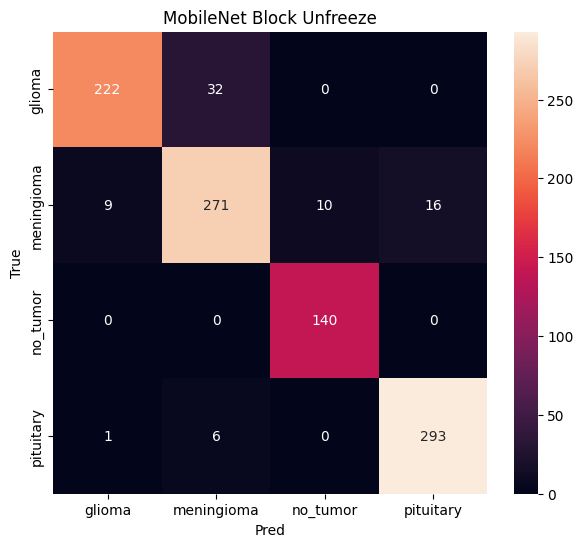

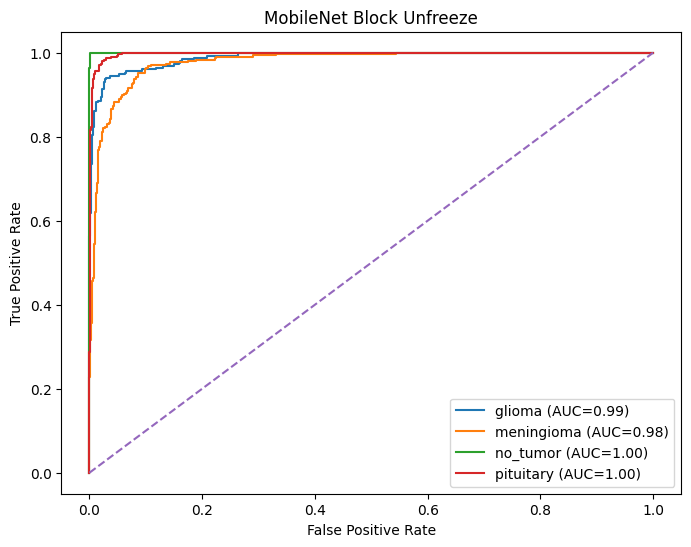

In [7]:
results = []

best_model = None
best_score = 0

for name, path in MODEL_PATHS.items():

    print("\n", "="*60)
    print("Model:", name)

    model = load_model(name, path)
    y_true, y_pred, y_prob = evaluate(model)
    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["Model"] = name

    results.append(metrics)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    plot_cm(y_true, y_pred, name)
    plot_roc(y_true, y_prob, name)

    score = metrics["F1"]

    if score > best_score:
        best_score = score
        best_model = name

## 8) Model Comparison

In [9]:
df = pd.DataFrame(results)
df = df[["Model","Accuracy","Precision","Recall","F1","AUC"]]
print(df)
print("========================================")
print("🏆 BEST MODEL:", best_model)
print("🔥 BEST F1 SCORE:", best_score)

                        Model  Accuracy  Precision  Recall        F1       AUC
0                  Simple CNN     0.780   0.791803   0.780  0.774007  0.949853
1          MobileNet Baseline     0.746   0.757032   0.746  0.740693  0.930922
2  MobileNet Partial Unfreeze     0.914   0.915001   0.914  0.913387  0.990288
3    MobileNet Block Unfreeze     0.926   0.926553   0.926  0.925570  0.991074
🏆 BEST MODEL: MobileNet Block Unfreeze
🔥 BEST F1 SCORE: 0.925569796028557


## 9) Evaluation Summary

This notebook evaluates four deep learning models for brain tumor classification using MRI images, including a baseline CNN and three variants of MobileNet with different fine-tuning strategies.

### Dataset
The evaluation is performed on a held-out test set containing 1000 MRI images across four classes: glioma, meningioma, no_tumor, and pituitary. All images are preprocessed using a standardized normalization pipeline consistent with ImageNet statistics.

### Evaluation Metrics
The models are evaluated using multiple performance metrics:
- Accuracy
- Precision (weighted)
- Recall (weighted)
- F1-score (weighted)
- ROC-AUC (one-vs-rest multiclass)

Additionally, confusion matrices and ROC curves are used for detailed error analysis and class-wise performance visualization.

### Results Summary
All MobileNet-based models significantly outperform the baseline CNN. The best performance is achieved by the MobileNet Block Unfreeze model, indicating that deeper fine-tuning of pretrained layers improves feature adaptation to medical imaging data.

### Best Model
The MobileNet Block Unfreeze model achieved the highest F1-score (0.9256) and AUC (0.9911), making it the most reliable model for this classification task.

### Conclusion
Fine-tuning pretrained convolutional models (MobileNet) significantly improves performance over training a CNN from scratch. The results demonstrate strong generalization ability and high separability between tumor classes, making the proposed approach suitable for medical diagnostic support systems.